In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os 
from data_loading import load_runs

RUN = ["4a_zppresel","4b_zppresel","4c_zppresel","4d_zppresel","5_zppresel"]
# rundata, mc_weights, data_pot = load_runs(
#     RUN,
#     data="bnb",
#     truth_filtered_sets=["nue", "drt"],
#     loadpi0variables=True,
#     loadshowervariables=True,
#     loadrecoveryvars=True,
#     loadsystematics=False,
#     load_crt_vars=True,
#     use_bdt = True,
#     load_lee=False,
#     enable_cache=True,
#     blinded=False,
#     # blinded=True,
# )

rundata, mc_weights, data_pot = load_runs(
    RUN,
    data="bnb",
    truth_filtered_sets=["nue", "drt", "nc_pi0"],
    use_truth_filters=True,
    loadpi0variables=True,
    loadshowervariables=True, # Loads in all variables we might want, including BDT variables (use_bdt=True asserts that these variables are loaded)
    loadrecoveryvars=True,
    loadsystematics=False,    # Set to false when we don't have event weights
    load_crt_vars=True,
    loadnumuvariables=True,
    use_bdt = False,          # Set use_BDT to false since we are training the BDT here, not using it
    use_numi=False,
    load_lee=False,
    enable_cache=True,
    blinded=True,             # Set blinded to true, no training on data!!
)

Loading run 4a_zppresel
Loading run 4b_zppresel
Loading run 4c_zppresel
Loading run 4d_zppresel
Loading run 5_zppresel


In [3]:
from microfit.histogram import Binning, Histogram, RunHistGenerator

In [4]:
flash_variables = [
    ("flash_y_flash_matching",25,  (-70,70), "flash_y_flash_matching"),
    ("flash_ywidth_flash_matching", 25, (0,60), "flash_ywidth_flash_matching"),
    ("flash_z_flash_matching", 25, (0,1050), "flash_z_flash_matching"),
    ("flash_zwidth_flash_matching", 25, (0,450), "flash_zwidth_flash_matching"),
    # ("nu_centerY", 25, (-160,160), "nu_centerY"),
    # ("nu_centerZ", 25, (0,1000), "nu_centerZ"),
    ("flash_pe_flash_matching", 25, (0,15000), "flash_pe_flash_matching"),
    # ("nu_totalCharge", 25, (0,40000), "nu_totalCharge")
]

slice_variables = [
    ("diffY", 25, (-200, 200), "ChargeY - FlashY [cm]"),
    ("normdiffY", 25, (-10, 10), "(ChargeY - FlashY) / FlashwidthY"),
    ("diffZ", 25, (-500, 500), "ChargeZ - FlashZ [cm]"),
    ("normdiffZ", 25, (-25, 25), "(ChargeZ - FlashZ) / FlashwidthZ"),
    ("normdiffZ", 25, (-1, 1), "(ChargeZ - FlashZ) / FlashwidthZ"),
    ("normdiffZ", 25, (-0.9, 1), "(ChargeZ - FlashZ) / FlashwidthZ"),
    ("fnl", 25, (-500, 500), "m.log(Charge/Flash) - ChargeX"),
]

slice_pass_id = [
    ("slice_orig_pass_id", 2, (0, 2), "slice_orig_pass_id"),
    ("slice_orig_pass_id", 1, (1, 2), "slice_orig_pass_id")
]

test_diffY = [
    ("diffY", 25, (-200, 200), "ChargeY - FlashY [cm]"),
    ("diffY", 25, (-200, 90), "ChargeY - FlashY [cm]"),
    ("diffY", 25, (-90, 200), "ChargeY - FlashY [cm]"),
    ("diffY", 25, (-90, 90), "ChargeY - FlashY [cm]"),
]

pelee_variables = [
    ("reco_e", 10, (0.15, 2.55), r"Reconstructed Energy [GeV]"),
    # ("reco_e", 14, (0.01, 1.55), "Reconstructed neutrino energy (GeV)"),
    # ("reco_e", 20, (0.15, 2.95), r"Reconstructed Neutrino Energy [GeV]"),
    # ("electron_e", 10, (0, 2.95), 'Reconstructed Electron Energy [GeV]'),
    # ("shr_theta", 21, (0, 3.14), r"Shower $\theta$"),
]

shr_energy = [
    ("shr_energy_tot_cali", 10, (0, 4), "shr_energy_tot_cali"),
]

In [5]:
# preselection = 'None'
# preselection = 'CRT'
# preselection = 'SLICE'
# preselection = 'ZP'
# preselection = 'ZPCRT'

# selection = 'None'
# selection = 'ZPLOOSESEL'
# selection = 'ZPBDT'
# selection = 'CRT'

presels = ['ZP', 'ZPCRT']
sels = ['None', 'ZPLOOSENEW']
# presels = ['None', 'SLICE', 'RESLICE', 'SLICERE', 'SLICET', 'SLICERT']
# sels = ['None', 'CRT']

# var = slice_pass_id[1]
# var = pelee_variables[0]
# var  = slice_variables[5]
var = shr_energy[0]

/exp/uboone/app/users/kpletcher/PELEE/PELEEMCC10/PELEE/microfit/histogram/run_hist_generator.py:163: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dataset_name"] = k
/exp/uboone/app/users/kpletcher/PELEE/PELEEMCC10/PELEE/microfit/run_plotter.py:132: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


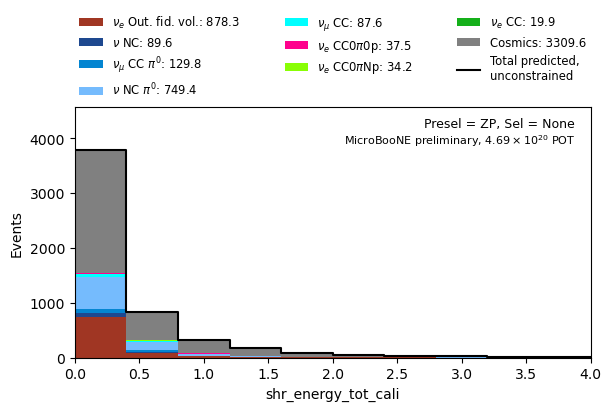

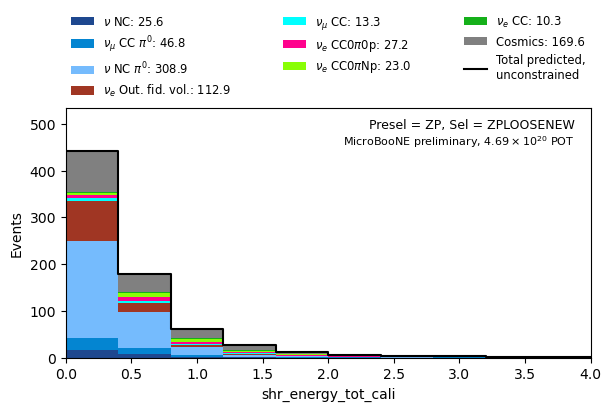

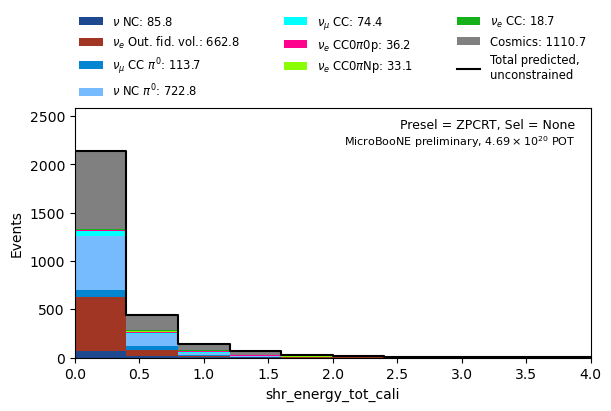

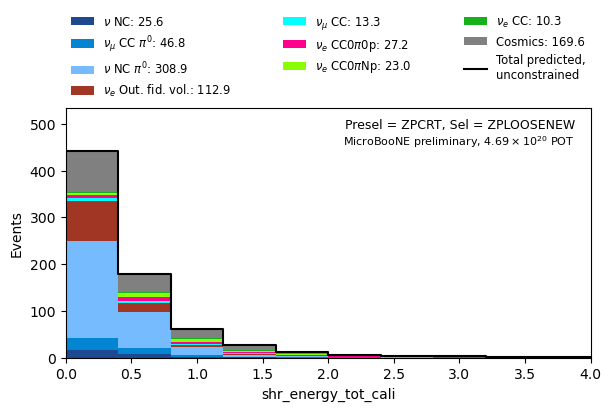

In [6]:
for p in presels:
    preselection = p
    for s in sels:
        selection = s

        binning_def = var
        binning = Binning.from_config(*binning_def)
        binning.label = preselection
        binning.set_selection(selection, preselection)

        signal_generator = RunHistGenerator(
            rundata,
            binning,
            data_pot=data_pot,
        )

        from microfit.run_plotter import RunHistPlotter

        plotter = RunHistPlotter(signal_generator)
        # ax = plotter.plot(
        #     category_column="category",
        #     include_multisim_errors=True,
        #     add_ext_error_floor=False,
        #     show_data_mc_ratio=True,
        #     show_chi_square=True,
        #     title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
        # )
        ax = plotter.plot(
            category_column="category",
            include_multisim_errors=False,
            add_ext_error_floor=False,
            show_data_mc_ratio=False,
            show_chi_square=False,
            show_total=False,           # Get rid of uncertainty
            title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
        )
    

In [7]:
# preselection = 'None'
# preselection = 'CRT'
# preselection = 'SLICE'
# preselection = 'ZP'
preselection = 'ZPCRT'

# selection = 'None'
# selection = 'ZPLOOSESEL'
# selection = 'ZPBDT'
# selection = 'CRT'

sels = ['None', 'ZPLOOSENEW']
# presels = ['None', 'SLICE', 'RESLICE', 'SLICERE', 'SLICET', 'SLICERT']
# sels = ['None', 'CRT']

# var = slice_pass_id[1]
# var = pelee_variables[0]
# var  = slice_variables[5]
var = shr_energy[0]

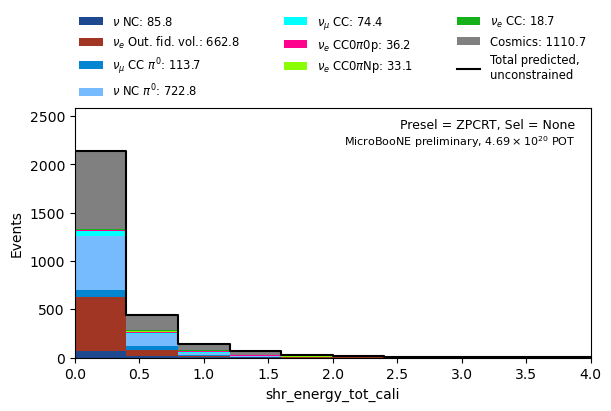

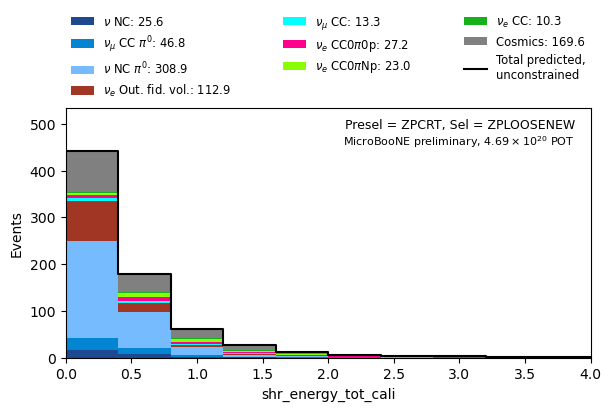

In [8]:
for s in sels:
    selection = s

    binning_def = var
    binning = Binning.from_config(*binning_def)
    binning.label = preselection
    binning.set_selection(selection, preselection)

    signal_generator = RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
    )

    from microfit.run_plotter import RunHistPlotter

    plotter = RunHistPlotter(signal_generator)
    # ax = plotter.plot(
    #     category_column="category",
    #     include_multisim_errors=True,
    #     add_ext_error_floor=False,
    #     show_data_mc_ratio=True,
    #     show_chi_square=True,
    #     title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
    # )
    # ax = plotter.plot(
    #     category_column="category",
    #     include_multisim_errors=False,
    #     add_ext_error_floor=False,
    #     show_data_mc_ratio=False,
    #     show_chi_square=False,
    #     title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
    # )

    ax = plotter.plot(
        category_column="category",
        include_multisim_errors=False,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
        show_total=False,           # Get rid of uncertainty
        title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
    )


In [9]:
# preselection = 'None'
# preselection = 'CRT'
# preselection = 'SLICE'
# preselection = 'ZP'
# preselection = 'ZPCRT'

selection = 'None'
# selection = 'ZPLOOSESEL'
# selection = 'ZPBDT'
# selection = 'CRT'

presels = ['None', 'ZP', 'ZPCRT']

# var = slice_pass_id[1]
# var = pelee_variables[0]
# var  = slice_variables[5]
var = shr_energy[0]

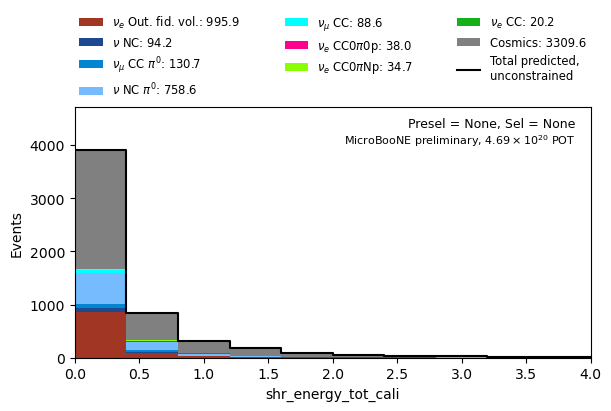

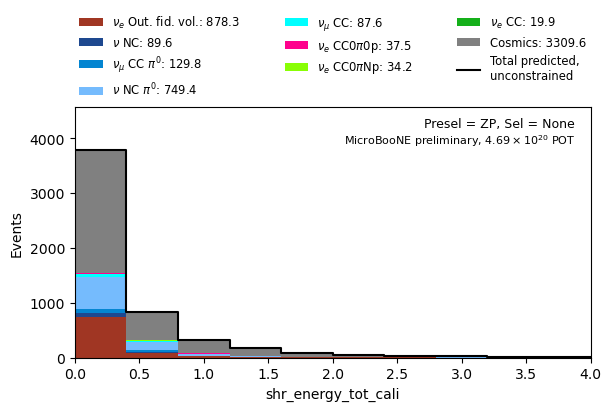

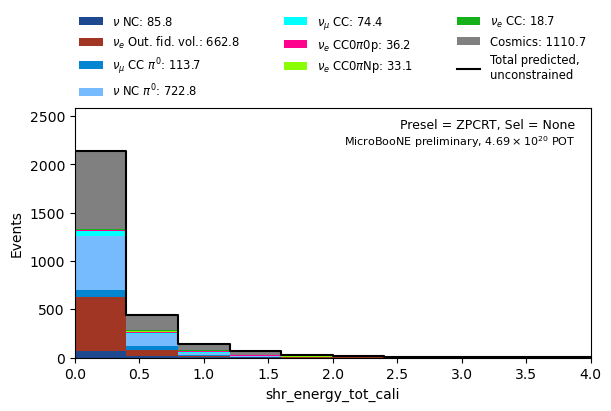

In [10]:
for p in presels:
    preselection = p

    binning_def = var
    binning = Binning.from_config(*binning_def)
    binning.label = preselection
    binning.set_selection(selection, preselection)

    signal_generator = RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
    )

    from microfit.run_plotter import RunHistPlotter

    plotter = RunHistPlotter(signal_generator)
    # ax = plotter.plot(
    #     category_column="category",
    #     include_multisim_errors=True,
    #     add_ext_error_floor=False,
    #     show_data_mc_ratio=True,
    #     show_chi_square=True,
    #     title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
    # )
    # ax = plotter.plot(
    #     category_column="category",
    #     include_multisim_errors=False,
    #     add_ext_error_floor=False,
    #     show_data_mc_ratio=False,
    #     show_chi_square=False,
    #     title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
    # )
    ax = plotter.plot(
        category_column="category",
        include_multisim_errors=False,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
        show_total=False,           # Get rid of uncertainty
        title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
    )


In [11]:
# for v in varSet:
#     binning_def = var
#     binning = Binning.from_config(*binning_def)
#     binning.label = preselection
#     binning.set_selection(selection, preselection)

#     signal_generator = RunHistGenerator(
#         rundata,
#         binning,
#         data_pot=data_pot,
#     )

#     from microfit.run_plotter import RunHistPlotter

#     plotter = RunHistPlotter(signal_generator)
#     ax = plotter.plot(
#         category_column="category",
#         include_multisim_errors=True,
#         add_ext_error_floor=False,
#         show_data_mc_ratio=True,
#         show_chi_square=True,
#         title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
#     )
#     # ax = plotter.plot(
#     #     category_column="category",
#     #     include_multisim_errors=False,
#     #     add_ext_error_floor=False,
#     #     show_data_mc_ratio=False,
#     #     show_chi_square=False,
#     #     title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
#     # )